In [11]:
import ee

ee.Authenticate() 
ee.Initialize(project="tidal-run-494108-k1")

In [12]:
import matplotlib.pyplot as plt
import numpy as np

aoi = ee.Geometry.Rectangle([103.62, 32.05, 103.70, 32.11])

s1 = (ee.ImageCollection('COPERNICUS/S1_GRD')
      .filterBounds(aoi)
      .filter(ee.Filter.eq('instrumentMode', 'IW'))
      .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
      .select('VV'))

def prep(img_col):
    img = img_col.mean().clip(aoi)
    return img.focal_mean(radius=30, units='meters')

pre  = prep(s1.filterDate('2017-06-01', '2017-06-24'))
post = prep(s1.filterDate('2017-06-25', '2017-07-26'))
diff = post.subtract(pre).rename('VV_change_dB')

diff = post.subtract(pre).rename('VV_change_dB')

print('pre scenes :', s1.filterDate('2017-06-01','2017-06-24').size().getInfo())
print('post scenes:', s1.filterDate('2017-06-25','2017-07-26').size().getInfo())

pre scenes : 2
post scenes: 2


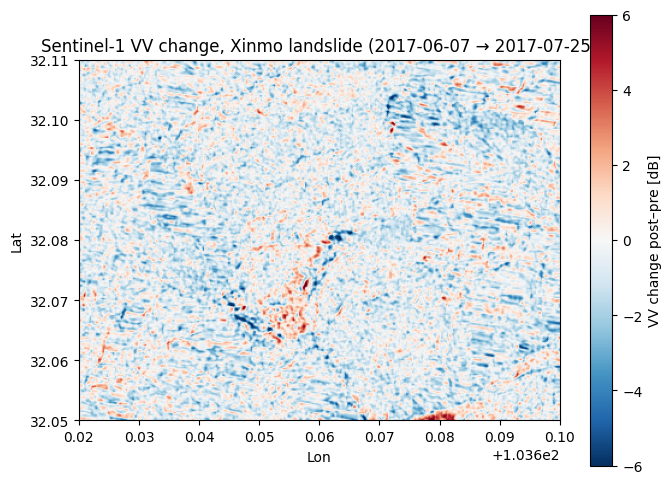

In [13]:
arr = ee.data.computePixels({
    'expression': diff,
    'fileFormat': 'NUMPY_NDARRAY',
    'grid': {
        'dimensions': {'width': 400, 'height': 320},
        'affineTransform': {
            'scaleX': (103.70 - 103.62) / 400, 'shearX': 0, 'translateX': 103.62,
            'shearY': 0, 'scaleY': -(32.11 - 32.05) / 320, 'translateY': 32.11,
        },
        'crsCode': 'EPSG:4326',
    },
})
vv = arr['VV_change_dB'].astype(float)

plt.figure(figsize=(7, 5))
im = plt.imshow(vv, cmap='RdBu_r', vmin=-6, vmax=6,
                extent=[103.62, 103.70, 32.05, 32.11], origin='upper')
plt.colorbar(im, label='VV change post–pre [dB]')
plt.title('Sentinel-1 VV change, Xinmo landslide (2017-06-07 → 2017-07-25)')
plt.xlabel('Lon'); plt.ylabel('Lat')
plt.tight_layout()
plt.savefig('vv_change.png', dpi=200)
plt.show()

In [23]:
aoi = ee.Geometry.Rectangle([103.62, 32.05, 103.70, 32.11])

c = ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
print('whole collection  :', c.limit(1).size().getInfo())          # should be 1
print('bounds only       :', c.filterBounds(aoi).size().getInfo())
print('bounds + date     :', c.filterBounds(aoi)
                              .filterDate('2017-05-01','2017-09-15').size().getInfo())
print('aoi coords        :', aoi.coordinates().getInfo())

whole collection  : 1
bounds only       : 703
bounds + date     : 10
aoi coords        : [[[103.62, 32.05], [103.7, 32.05], [103.7, 32.11], [103.62, 32.11], [103.62, 32.05]]]


In [27]:
import ee, numpy as np, matplotlib.pyplot as plt

aoi = ee.Geometry.Rectangle([103.62, 32.05, 103.70, 32.11])

def mask_s2(img):
    qa = img.select('QA60')
    cloud  = qa.bitwiseAnd(1 << 10).eq(0)
    cirrus = qa.bitwiseAnd(1 << 11).eq(0)
    return img.updateMask(cloud.And(cirrus)).divide(10000)

base = ee.ImageCollection('COPERNICUS/S2_HARMONIZED').filterBounds(aoi)

pre  = base.filterDate('2017-05-01', '2017-06-24').map(mask_s2).median().clip(aoi)
post = base.filterDate('2017-06-25', '2017-09-15').map(mask_s2).median().clip(aoi)

print('pre scenes :', base.filterDate('2017-05-01','2017-06-24').size().getInfo())
print('post scenes:', base.filterDate('2017-06-25','2017-09-15').size().getInfo())
print('pre bands  :', pre.bandNames().getInfo())

pre scenes : 3
post scenes: 7
pre bands  : ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B10', 'B11', 'B12', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']


In [33]:
def to_array(img, bands, w=512, h=410):
    res = ee.data.computePixels({
        'expression': img.select(bands),
        'fileFormat': 'NUMPY_NDARRAY',
        'grid': {
            'dimensions': {'width': w, 'height': h},
            'affineTransform': {
                'scaleX': (103.70-103.62)/w, 'shearX': 0, 'translateX': 103.62,
                'shearY': 0, 'scaleY': -(32.11-32.05)/h, 'translateY': 32.11},
            'crsCode': 'EPSG:4326'}})
    return res

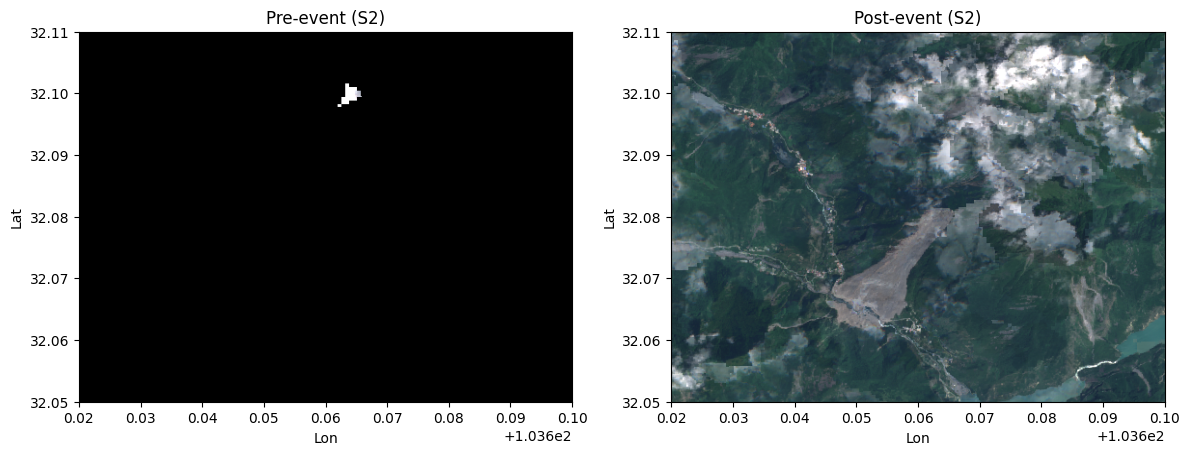

In [32]:
ext = [103.62, 103.70, 32.05, 32.11]

def rgb(img):
    a = to_array(img, ['B4','B3','B2'])
    return np.clip(np.dstack([a['B4'], a['B3'], a['B2']]) * 3.5, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(12,5))
ax[0].imshow(rgb(pre),  extent=ext, origin='upper'); ax[0].set_title('Pre-event (S2)')
ax[1].imshow(rgb(post), extent=ext, origin='upper'); ax[1].set_title('Post-event (S2)')
for a in ax: a.set_xlabel('Lon'); a.set_ylabel('Lat')
plt.tight_layout(); plt.savefig('s2_before_after.png', dpi=200); plt.show()

Affected area (ha): 0


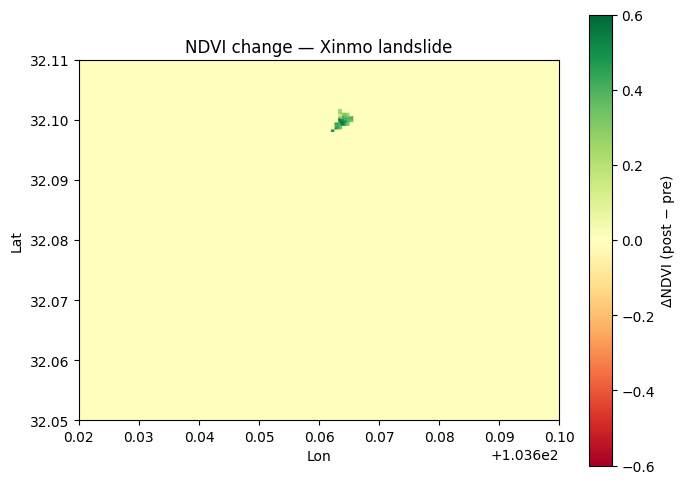

In [30]:
ndvi = lambda img: img.normalizedDifference(['B8','B4']).rename('NDVI')
dndvi = ndvi(post).subtract(ndvi(pre)).rename('dNDVI')

scar = dndvi.lt(-0.25)

area = (scar.multiply(ee.Image.pixelArea())
            .reduceRegion(ee.Reducer.sum(), aoi, scale=10, maxPixels=1e9))
print('Affected area (ha):', ee.Number(area.get('dNDVI')).divide(1e4).getInfo())

d = to_array(dndvi, ['dNDVI'])['dNDVI'].astype(float)
plt.figure(figsize=(7,5))
im = plt.imshow(d, cmap='RdYlGn', vmin=-0.6, vmax=0.6, extent=ext, origin='upper')
plt.colorbar(im, label='ΔNDVI (post − pre)')
plt.title('NDVI change — Xinmo landslide'); plt.xlabel('Lon'); plt.ylabel('Lat')
plt.tight_layout(); plt.savefig('s2_ndvi_change.png', dpi=200); plt.show()